# 03 · Convolutional Neural Networks, Transfer Learning and Multi-Task Learning

**Contents**

1. Why MLPs are a poor fit for images
2. The convolution operation (worked example)
3. Output size: padding and stride (derivation)
4. Channels and parameter count
5. Weight sharing and translation equivariance (proof)
6. Pooling
7. Receptive field
8. A small CNN, trained (and compared with an MLP)
9. What the filters learn
10. Deep architectures and residual connections
11. Transfer learning
12. Multi-task learning and loss weighting

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import torch, torch.nn as nn, torch.nn.functional as F
plt.rcParams.update({"figure.dpi": 90, "axes.grid": True, "grid.alpha": 0.3,
                     "axes.spines.top": False, "axes.spines.right": False})
rng = np.random.default_rng(0); torch.manual_seed(0)

## 1. Why MLPs are a poor fit for images

An image is a grid $H\times W$ with $C$ channels (1 for grey, 3 for RGB). An MLP flattens it into a vector, which causes two problems:

- **Too many parameters.** A 224×224×3 image has 150,528 inputs; a first dense layer with 1,000 units already needs **150 million** weights.
- **No spatial prior.** After flattening, pixels $(0,0)$ and $(0,1)$ are as unrelated as $(0,0)$ and $(223,223)$. A cat in the top-left corner and the same cat in the bottom-right are unrelated inputs, and the MLP must learn to detect it separately at every position.

Images have **local** structure (edges, textures, parts are made of nearby pixels), and the same pattern can appear **anywhere**. A convolutional layer builds both facts into the architecture.

## 2. The convolution operation

A convolutional layer slides a small **filter** (kernel) $\mathbf{K}\in\mathbb{R}^{F\times F}$ over the image and computes a weighted sum at each position:

$$
O[i,j] = \sum_{u=0}^{F-1}\sum_{v=0}^{F-1} I[i+u,\;j+v]\;K[u,v] + b .
$$

(Strictly, this is *cross-correlation*: mathematical convolution flips the kernel. Since the kernel is learned, the difference doesn't matter, and every library computes the formula above.) The output $O$ is a **feature map**: it is large wherever the image locally looks like the filter.

**Worked example.** A 5×5 image with a vertical edge, and a 3×3 vertical-edge filter:

$$
I = \begin{bmatrix}0&0&0&1&1\\0&0&0&1&1\\0&0&0&1&1\\0&0&0&1&1\\0&0&0&1&1\end{bmatrix},\qquad
K = \begin{bmatrix}-1&0&1\\-1&0&1\\-1&0&1\end{bmatrix}.
$$

At the top-left position $(0,0)$ the window covers columns 0–2, all zeros, so $O[0,0] = 0$. At $(0,1)$ the window covers columns 1–3: the right column of the window is all 1s, times $+1$, so $O[0,1] = 3$. At $(0,2)$, columns 2–4: the middle and right columns are 1, giving $0\cdot3 + 1\cdot3 = 3$. The output is $3\times3$ with rows $[0, 3, 3]$: the filter "lights up" at the edge.

In [2]:
I = np.array([[0, 0, 0, 1, 1]] * 5, dtype=float)
K = np.array([[-1, 0, 1]] * 3, dtype=float)

def conv2d(I, K, stride=1, pad=0):
    I = np.pad(I, pad); F_ = K.shape[0]
    H_out = (I.shape[0] - F_) // stride + 1; W_out = (I.shape[1] - F_) // stride + 1
    O = np.zeros((H_out, W_out))
    for i in range(H_out):
        for j in range(W_out):
            O[i, j] = np.sum(I[i * stride:i * stride + F_, j * stride:j * stride + F_] * K)
    return O

print("our conv2d:\n", conv2d(I, K))
print("torch F.conv2d:\n", F.conv2d(torch.tensor(I)[None, None], torch.tensor(K)[None, None])[0, 0].numpy())

our conv2d:
 [[0. 3. 3.]
 [0. 3. 3.]
 [0. 3. 3.]]
torch F.conv2d:
 [[0. 3. 3.]
 [0. 3. 3.]
 [0. 3. 3.]]


## 3. Output size: padding and stride

- **Padding** $P$: add $P$ rows/columns of zeros around the input, so that border pixels are covered and the size doesn't shrink.
- **Stride** $S$: move the filter $S$ pixels at a time (downsampling).

**Derivation.** Along one axis the padded input has length $H + 2P$. The filter's first index can be $0, S, 2S, \dots, kS$, as long as the filter fits: $kS + F \le H + 2P$, i.e. $k \le \frac{H + 2P - F}{S}$. The number of valid positions is $k_{\max} + 1$:

$$
\boxed{H_{\text{out}} = \left\lfloor\frac{H + 2P - F}{S}\right\rfloor + 1}
$$

Examples: $F=3, P=1, S=1$ keeps the size ("same" padding); $F=3, P=0, S=1$ loses 2 pixels; $F=2, S=2$ halves it.

In [3]:
for H, F_, P, S in [(28, 3, 1, 1), (28, 3, 0, 1), (28, 5, 2, 2), (224, 7, 3, 2)]:
    out = F.conv2d(torch.zeros(1, 1, H, H), torch.zeros(1, 1, F_, F_), stride=S, padding=P).shape[-1]
    print(f"H={H:3d} F={F_} P={P} S={S}:  formula {(H + 2 * P - F_) // S + 1:3d}   torch {out:3d}")

H= 28 F=3 P=1 S=1:  formula  28   torch  28
H= 28 F=3 P=0 S=1:  formula  26   torch  26
H= 28 F=5 P=2 S=2:  formula  14   torch  14
H=224 F=7 P=3 S=2:  formula 112   torch 112


## 4. Channels and parameter count

Real inputs and feature maps have several **channels**. A layer maps $C_{\text{in}}$ input channels to $C_{\text{out}}$ output channels. Each output channel has its own filter of shape $C_{\text{in}}\times F\times F$ (it looks at all input channels at once) plus a bias:

$$
O_c[i,j] = \sum_{c'=1}^{C_{\text{in}}}\sum_{u,v} I_{c'}[i+u, j+v]\,K_{c,c'}[u,v] + b_c, \qquad
\#\text{params} = (C_{\text{in}}F^2 + 1)\,C_{\text{out}} .
$$

A tensor of images has shape $(B, C, H, W)$ in PyTorch. Example: a conv layer 3 → 64 channels with $3\times3$ filters has $(27+1)\cdot64 = 1{,}792$ parameters, **independent of the image size**. A dense layer from a 224×224×3 image to a 224×224×64 output would need $\approx 10^{11}$.

## 5. Weight sharing and translation equivariance

The **same** filter is used at every position (**weight sharing**). Two consequences:

1. **Few parameters**, as computed above.
2. **Translation equivariance**: shifting the input shifts the output by the same amount.

*Proof* (stride 1, ignoring borders). Let $I'[i,j] = I[i-s, j-t]$ be the image shifted by $(s,t)$. Then
$$
O'[i,j] = \sum_{u,v}I'[i+u, j+v]K[u,v] = \sum_{u,v}I[i-s+u, j-t+v]K[u,v] = O[i-s, j-t].
$$
The feature map of the shifted image is the shifted feature map. $\blacksquare$

So a pattern detector learned at one position works at every position. (A conv layer can be written as a dense layer whose weight matrix is **sparse**, since each output sees only $F\times F$ inputs, and **shared**, since the same weights repeat on every row. It is a heavily constrained dense layer, and the constraint is the prior.)

## 6. Pooling

**Max pooling** takes the maximum over each $2\times2$ window with stride 2: $O[i,j] = \max_{u,v\in\{0,1\}}A[2i+u, 2j+v]$. **Average pooling** takes the mean.

- Halves height and width: less computation, and deeper layers see a larger region.
- No parameters.
- Adds **local invariance**: moving a feature by one pixel inside a window often doesn't change the max.

Convolutions are *equivariant* (the output moves with the input); pooling and the final classifier make the network approximately *invariant* (the class doesn't change). For classification we want invariance. For localisation (e.g. predicting eye coordinates, face lab) we need to keep spatial information, so too much pooling hurts.

**Global average pooling** averages each channel over the whole map, turning $(C, H, W)$ into a $C$-vector. Modern CNNs (ResNet) use it before the final linear layer.

## 7. Receptive field

The **receptive field** of a unit is the region of the input image that can affect it. A $3\times3$ conv on the input sees $3\times3$. Each later layer with filter size $F_l$ adds $(F_l - 1)$ units **of its own input**, and one unit of layer $l-1$ spans $\prod_{i<l}S_i$ input pixels (the product of the strides before it). So

$$
r_0 = 1, \qquad r_l = r_{l-1} + (F_l - 1)\prod_{i=1}^{l-1}S_i .
$$

For the architecture of the Fashion-MNIST CNN lab (conv3 → pool2 → conv3 → pool2):

| Layer | $F_l$ | $S_l$ | jump $\prod_{i<l}S_i$ | receptive field $r_l$ |
|---|---|---|---|---|
| conv 3×3, stride 1 | 3 | 1 | 1 | $1 + 2\cdot1 = 3$ |
| max-pool 2×2, stride 2 | 2 | 2 | 1 | $3 + 1\cdot1 = 4$ |
| conv 3×3, stride 1 | 3 | 1 | 2 | $4 + 2\cdot2 = 8$ |
| max-pool 2×2, stride 2 | 2 | 2 | 2 | $8 + 1\cdot2 = 10$ |

Stacking layers (and downsampling) grows the receptive field, so deep units see large parts of the image: early layers detect edges, middle layers textures and parts, deep layers objects. Two stacked $3\times3$ convs see $5\times5$ with fewer parameters ($2\cdot9 = 18$ vs 25 per channel pair) and an extra non-linearity. That is why modern nets use small filters.

In [4]:
def receptive_field(layers):          # layers = [(F, S), ...]
    r, jump = 1, 1
    for F_, S in layers:
        r += (F_ - 1) * jump; jump *= S
    return r
print("lab CNN (conv3, pool2, conv3, pool2):", receptive_field([(3, 1), (2, 2), (3, 1), (2, 2)]))

# empirical check: the gradient of one output unit w.r.t. the input is non-zero exactly on its receptive field
# (average pooling, so that every input of a window passes gradient; max pooling passes it only to the argmax)
net = nn.Sequential(nn.Conv2d(1, 1, 3, padding=1), nn.AvgPool2d(2), nn.Conv2d(1, 1, 3, padding=1), nn.AvgPool2d(2))
with torch.no_grad():
    for p in net.parameters(): p.fill_(1.0)          # all-ones weights so every path counts
x = torch.rand(1, 1, 28, 28, requires_grad=True)
net(x)[0, 0, 3, 3].backward()
nz = (x.grad[0, 0] != 0).nonzero()
print("empirical extent of the gradient:", (nz[:, 0].max() - nz[:, 0].min() + 1).item(), "x", (nz[:, 1].max() - nz[:, 1].min() + 1).item())

lab CNN (conv3, pool2, conv3, pool2): 10
empirical extent of the gradient: 10 x 10


The empirical extent matches the formula. With **max** pooling, a given unit's gradient flows only through the winning position of each window, so for a specific input fewer pixels actually matter. The receptive field is the largest region that *can* matter.

## 8. A small CNN, trained

Typical pattern: `[Conv → ReLU (→ BatchNorm)] × k → Pool`, repeated, then flatten (or global-average-pool) → dense → logits. Channels grow as the spatial size shrinks.

We use the digits dataset (8×8 images, as in notebook 02), with the same small training set of 500 images, and compare a CNN against an MLP.

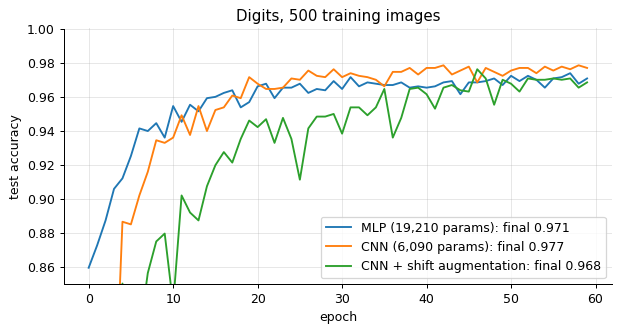

In [5]:
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from torch.utils.data import TensorDataset, DataLoader

d = load_digits()
Xd = (d.images / 16.0).astype(np.float32)[:, None]          # (N, 1, 8, 8)
X_tr, X_te, y_tr, y_te = train_test_split(Xd, d.target, train_size=500, stratify=d.target, random_state=0)
Xtr_t, ytr_t, Xte_t, yte_t = map(torch.tensor, (X_tr, y_tr, X_te, y_te))

class SmallCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 16, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),     # 16 x 4 x 4
            nn.Conv2d(16, 32, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2))    # 32 x 2 x 2
        self.head = nn.Sequential(nn.Flatten(), nn.Dropout(0.3), nn.Linear(32 * 2 * 2, 10))
    def forward(self, x): return self.head(self.features(x))

mlp = nn.Sequential(nn.Flatten(), nn.Linear(64, 256), nn.ReLU(), nn.Dropout(0.3), nn.Linear(256, 10))

def shift(x):
    """Data augmentation: shift each image by a random -1..1 pixels in each direction, zero fill."""
    xp = F.pad(x, (1, 1, 1, 1)); B = x.shape[0]
    dx, dy = torch.randint(0, 3, (B,)), torch.randint(0, 3, (B,))
    return torch.stack([xp[b, :, dy[b]:dy[b] + 8, dx[b]:dx[b] + 8] for b in range(B)])

def fit(model, epochs=60, augment=False, seed=0):
    torch.manual_seed(seed); np.random.seed(seed)
    opt = torch.optim.Adam(model.parameters(), lr=3e-3)
    loader = DataLoader(TensorDataset(Xtr_t, ytr_t), batch_size=32, shuffle=True)
    accs = []
    for _ in range(epochs):
        model.train()
        for xb, yb in loader:
            if augment: xb = shift(xb)
            opt.zero_grad(); F.cross_entropy(model(xb), yb).backward(); opt.step()
        model.eval()
        with torch.no_grad(): accs.append((model(Xte_t).argmax(1) == yte_t).float().mean().item())
    return accs

n_params = lambda mdl: sum(p.numel() for p in mdl.parameters())
runs = {f"MLP ({n_params(mlp):,} params)": fit(mlp)}
cnn = SmallCNN(); runs[f"CNN ({n_params(cnn):,} params)"] = fit(cnn)
cnn_aug = SmallCNN(); runs["CNN + shift augmentation"] = fit(cnn_aug, augment=True)

plt.figure(figsize=(7, 3.8))
for k, v in runs.items(): plt.plot(v, label=f"{k}: final {v[-1]:.3f}")
plt.ylim(0.85, 1.0); plt.xlabel("epoch"); plt.ylabel("test accuracy"); plt.legend(); plt.title("Digits, 500 training images")
plt.tight_layout(); plt.show()

The CNN matches or beats the MLP with about **a third of the parameters**. On larger images (Fashion-MNIST, faces) the gap grows, because the prior matters more as images get bigger: the MLP's parameter count explodes with the number of pixels, the CNN's does not.

The shift augmentation does **not** help here (on repeated runs it is within noise of the plain CNN). The scikit-learn digits are already centred, and a 1-pixel shift is 12 % of an 8×8 image, so it mostly adds variation that the test set does not have. Augmentation helps when it reproduces variation that really occurs in new data. In the Fashion-MNIST lab, horizontal flips and dropout clearly reduced overfitting. Always check it on validation data.

## 9. What the filters learn

Below: the 16 learned $3\times3$ filters of the first layer, and the 16 feature maps they produce for one digit. We also verify equivariance: shifting the input by one pixel shifts the feature maps by one pixel.

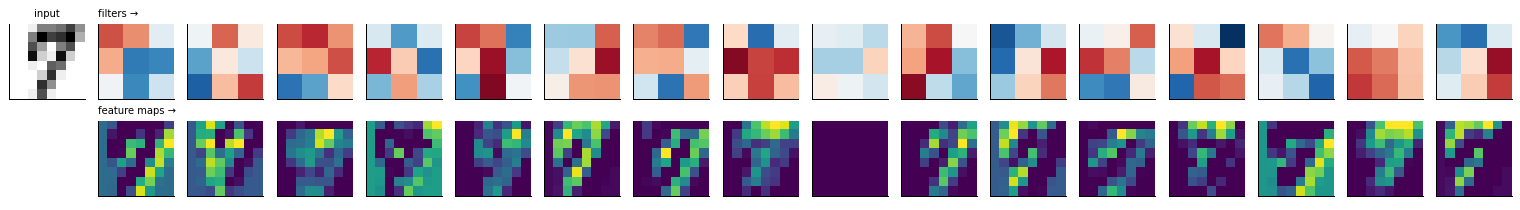

max |conv(shift(x)) - shift(conv(x))| away from borders: 0.0


In [6]:
W1 = cnn.features[0].weight.detach()[:, 0]                      # (16, 3, 3)
x0 = Xte_t[:1]
with torch.no_grad(): fmap = F.relu(cnn.features[0](x0))[0]    # (16, 8, 8)
fig, axes = plt.subplots(2, 17, figsize=(17, 2.4))
axes[0, 0].imshow(x0[0, 0], cmap="gray_r"); axes[0, 0].set_title("input", fontsize=8)
axes[1, 0].axis("off")
for k in range(16):
    axes[0, k + 1].imshow(W1[k], cmap="RdBu_r", vmin=-W1.abs().max(), vmax=W1.abs().max())
    axes[1, k + 1].imshow(fmap[k], cmap="viridis")
for ax in axes.ravel(): ax.set_xticks([]); ax.set_yticks([]); ax.grid(False)
axes[0, 1].set_title("filters →", fontsize=8, loc="left"); axes[1, 1].set_title("feature maps →", fontsize=8, loc="left")
plt.tight_layout(); plt.show()

x_shift = torch.roll(x0, shifts=1, dims=3)
with torch.no_grad():
    f_shift = cnn.features[0](x_shift)[0]; f_orig = cnn.features[0](x0)[0]
inner = (slice(None), slice(1, -1), slice(2, -1))          # compare away from the borders
print("max |conv(shift(x)) - shift(conv(x))| away from borders:",
      (f_shift[inner] - torch.roll(f_orig, 1, dims=2)[inner]).abs().max().item())

## 10. Deep architectures and residual connections

Milestones on ImageNet (1.2 M images, 1000 classes): **LeNet** (1998, digits), **AlexNet** (2012, ReLU + dropout + GPUs), **VGG** (2014, stacks of 3×3 convs), **ResNet** (2015, 50–152 layers), then EfficientNet, ConvNeXt, and vision transformers.

**Why depth used to fail.** Beyond ~20 layers plain CNNs got *worse*, even on the training set. That is an optimisation problem (vanishing gradients, notebook 01), not overfitting.

**Residual block.** Instead of learning a mapping $H(\mathbf{x})$ directly, learn a correction $F(\mathbf{x})$ and add the input back:
$$
\mathbf{y} = \mathbf{x} + F(\mathbf{x}) .
$$
- If the best thing a block can do is (almost) nothing, it only needs $F\approx 0$, which is easy (weights near 0). A plain block would have to learn the identity map.
- **Gradient flow:** $\frac{\partial J}{\partial\mathbf{x}} = \frac{\partial J}{\partial\mathbf{y}}\Big(\mathbf{I} + \frac{\partial F}{\partial\mathbf{x}}\Big)$. The identity term gives the gradient a direct path through every block, so it cannot vanish just because $\partial F/\partial\mathbf{x}$ is small. Through $L$ blocks, the gradient contains the term $\frac{\partial J}{\partial\mathbf{y}_L}$ unchanged.

The same trick is used in every transformer layer (notebook 05).

## 11. Transfer learning

Training a ResNet-50 from scratch needs millions of labelled images. But the features learned on ImageNet (edges → textures → parts) are useful for almost any image task. **Transfer learning**: start from pre-trained weights, replace the final classification layer by a head for your task, and train on your (small) dataset.

| Strategy | What is trained | When |
|---|---|---|
| **Feature extraction** | only the new head (backbone frozen, `requires_grad=False`) | very little data, or task similar to ImageNet |
| **Fine-tuning** | everything, with a small learning rate | more data, or a task that differs from ImageNet |
| **Freeze, then unfreeze** | head first for 1–2 epochs, then all | avoids random-head gradients damaging good features |
| **Discriminative LRs** | lower LR for the backbone than for the head | a common extra gain |

Practical details from the face labs:
- **Use the pre-training preprocessing**: resize, then normalise with the ImageNet mean/std $(0.485, 0.456, 0.406)$ / $(0.229, 0.224, 0.225)$. The filters expect inputs from that distribution.
- **BatchNorm** layers of the backbone carry running statistics. Fine-tune with `model.train()`, evaluate with `model.eval()`.
- Normalise regression targets (e.g. eye coordinates divided by image width/height, ages standardised) so the loss is on a sensible scale.

```python
import torchvision
backbone = torchvision.models.resnet50(weights="IMAGENET1K_V2")
backbone.fc = nn.Identity()                  # 2048-dim features
head = nn.Sequential(nn.Linear(2048, 512), nn.ReLU(), nn.Dropout(0.2), nn.Linear(512, 4))
model = nn.Sequential(backbone, head)
optimizer = torch.optim.AdamW([{"params": backbone.parameters(), "lr": 1e-4},
                               {"params": head.parameters(),     "lr": 1e-3}], weight_decay=1e-4)
```

## 12. Multi-task learning and loss weighting

**Multi-task learning (MTL)**: one shared trunk $\mathbf{h} = f_{\boldsymbol{\theta}}(\mathbf{x})$ and one small head per task, $\hat{y}_k = g_{\boldsymbol{\phi}_k}(\mathbf{h})$ (face lab: eye coordinates, gender, age). The loss is a weighted sum:

$$
J = \sum_k\lambda_k J_k, \qquad \nabla_{\boldsymbol{\theta}}J = \sum_k\lambda_k\nabla_{\boldsymbol{\theta}}J_k .
$$

- **Why it can help**: the trunk must produce features useful for all tasks, which acts as a regulariser (it can't overfit one task's quirks). It also gets more supervision per image, and deployment needs one forward pass instead of several.
- **Why it can hurt (negative transfer)**: if the task gradients point in conflicting directions, the shared trunk compromises.
- **The practical problem: loss scales.** The trunk gradient is a sum, so the task with the largest loss magnitude dominates. In the face lab the raw losses differ by 6 orders of magnitude: eye MSE on $[0,1]$ coordinates $\approx 6\times10^{-5}$, gender BCE $\approx 0.69$, age MSE in years² $\approx 73$. Unweighted, the network would learn almost only age.

**Fix 1: standardise the targets.** Train each regression head on $z$-scores $(y-\mu_k)/\sigma_k$. Then every MSE starts around 1, comparable to BCE at chance ($\log 2\approx0.69$).

**Fix 2: learned weights from maximum likelihood** (Kendall et al., 2018). Model task $k$ as Gaussian with its own noise level, $y_k\sim\mathcal{N}(\hat y_k, \sigma_k^2)$. The negative log-likelihood is
$$
-\log p(y_k) = \frac{(y_k - \hat y_k)^2}{2\sigma_k^2} + \log\sigma_k + \text{const},
\qquad\Rightarrow\qquad
J = \sum_k\frac{1}{2\sigma_k^2}J_k + \log\sigma_k ,
$$
with $\sigma_k$ learned jointly with the network. A noisy or large-scale task gets a large $\sigma_k$ and hence a small weight; the $\log\sigma_k$ term stops $\sigma_k\to\infty$. Setting $\partial J/\partial\sigma_k = 0$ gives $\sigma_k^2 = J_k$, i.e. **weights inversely proportional to each task's loss**. That is the same effect as standardising, discovered automatically, and the same MLE reasoning as always.

**Always compare with trivial baselines** (mean coordinate, majority class, mean age) before believing a multi-task model learned something.

## Summary

- Convolution = the same small filter applied at every position: few parameters, translation equivariance. Output size $\lfloor(H+2P-F)/S\rfloor + 1$; parameters $(C_{\text{in}}F^2+1)C_{\text{out}}$.
- Pooling downsamples and adds local invariance; the receptive field grows as $r_l = r_{l-1} + (F_l-1)\prod_{i<l}S_i$.
- CNN = stacks of conv–ReLU–pool, then a dense head. It matches or beats an MLP on images with far fewer parameters. Augmentation helps only when it mimics variation that really occurs.
- Residual connections $\mathbf{y} = \mathbf{x} + F(\mathbf{x})$ keep gradients flowing through very deep networks.
- Transfer learning: reuse ImageNet backbones, with their preprocessing; freeze or fine-tune with small/discriminative learning rates.
- Multi-task: shared trunk + heads, $J = \sum\lambda_kJ_k$; balance the loss scales (standardise targets, or learn $\sigma_k$ by MLE).